
Total Files: 35
Processing: Patient_1.csv
Processing: Patient_10.csv
Processing: Patient_11.csv
Processing: Patient_12.csv
Processing: Patient_13.csv
Processing: Patient_14.csv
Processing: Patient_15.csv
Processing: Patient_16.csv
Processing: Patient_17.csv
Processing: Patient_18.csv
Processing: Patient_19.csv
Processing: Patient_2.csv
Processing: Patient_20.csv
Processing: Patient_21.csv
Processing: Patient_22.csv
Processing: Patient_23.csv
Processing: Patient_24.csv
Processing: Patient_25.csv
Processing: Patient_26.csv
Processing: Patient_27.csv
Processing: Patient_28.csv
Processing: Patient_29.csv
Processing: Patient_3.csv
Processing: Patient_30.csv
Processing: Patient_31.csv
Processing: Patient_32.csv
Processing: Patient_33.csv
Processing: Patient_34.csv
Processing: Patient_35.csv
Processing: Patient_4.csv
Processing: Patient_5.csv
Processing: Patient_6.csv
Processing: Patient_7.csv
Processing: Patient_8.csv
Processing: Patient_9.csv

PPG Shape: (3500, 1500)

NaN Count: 0

Min: -1

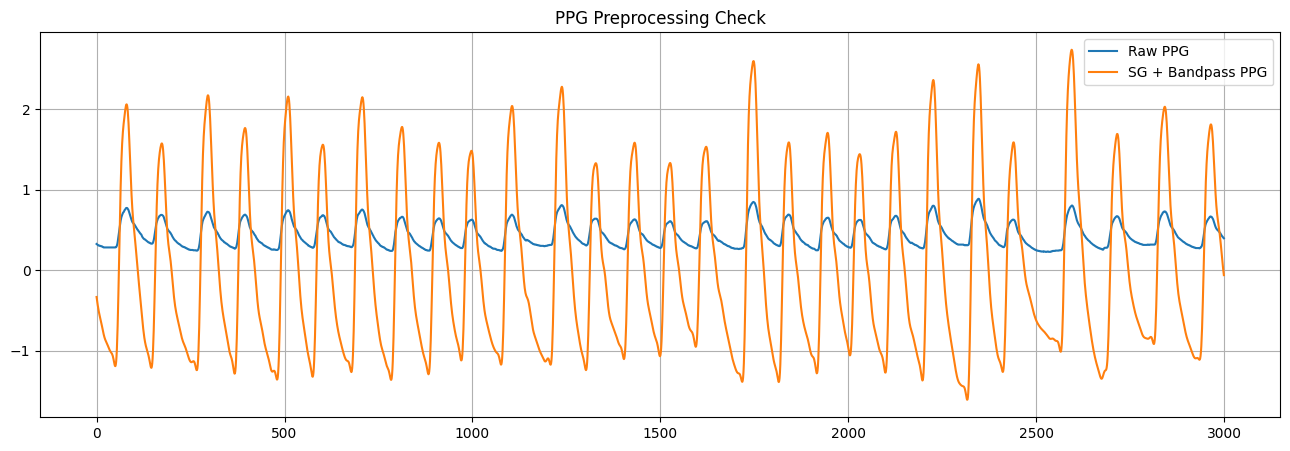

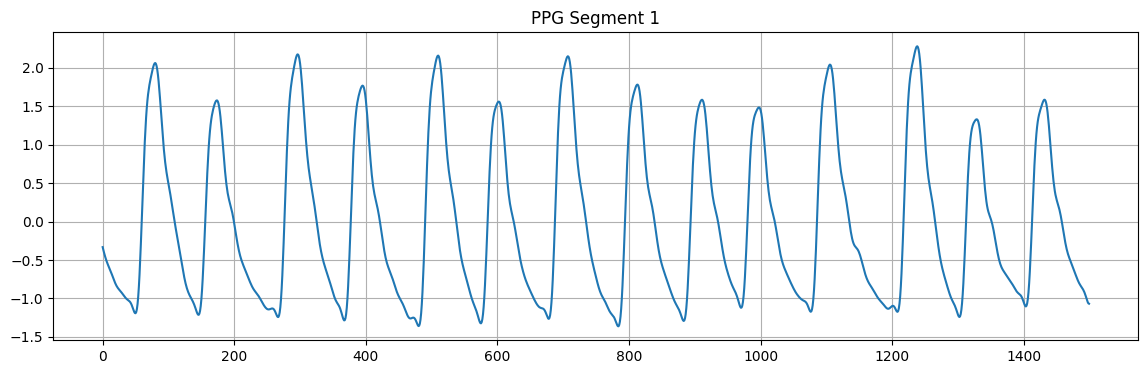

In [2]:
import os
import pandas as pd
import numpy as np

from scipy.signal import butter
from scipy.signal import filtfilt
from scipy.signal import savgol_filter

import matplotlib.pyplot as plt


# ======================================
# DATASET PATH
# ======================================

ROOT = r"C:\Users\tarak\Patient_Files"

FS = 125
WINDOW = 1500


# ======================================
# PPG BANDPASS FILTER
# ======================================

def bandpass_ppg(x):

    try:

        b, a = butter(

            4,

            [

                0.5/(FS/2),

                8/(FS/2)

            ],

            btype="band"

        )

        x = filtfilt(

            b,

            a,

            x

        )

        x = np.nan_to_num(

            x,

            nan=0,

            posinf=0,

            neginf=0

        )

        return x

    except:

        return np.nan_to_num(

            x,

            nan=0,

            posinf=0,

            neginf=0

        )


# ======================================
# SAVITZKY GOLAY FILTER
# ======================================

def sg(x):

    x = np.nan_to_num(

        x

    )

    return savgol_filter(

        x,

        window_length=11,

        polyorder=3

    )


# ======================================
# NORMALIZE
# ======================================

def normalize(x):

    x = np.nan_to_num(

        x,

        nan=0,

        posinf=0,

        neginf=0

    )

    std = np.std(

        x

    )

    if std < 1e-8:

        return np.zeros_like(

            x

        )

    return (

        x -

        np.mean(x)

    ) / (

        std

    )


# ======================================
# SEGMENT
# ======================================

def segment(x):

    out=[]

    for i in range(

        0,

        len(x),

        WINDOW

    ):

        s=x[

            i:

            i+WINDOW

        ]

        if len(s)==WINDOW:

            if not np.isnan(

                s

            ).any():

                out.append(

                    s

                )

    return out


# ======================================
# MAIN
# ======================================

segments=[]

files=sorted([

f

for f in os.listdir(

ROOT

)

if f.endswith(

".csv"

)

])


print(

"\nTotal Files:",

len(files)

)


for file in files:

    print(

        "Processing:",

        file

    )

    try:

        df=pd.read_csv(

            os.path.join(

                ROOT,

                file

            )

        )

        ppg=(

            df["PPG"]

            .values

            .astype(

                np.float32

            )

        )

        ppg=np.nan_to_num(

            ppg,

            nan=0,

            posinf=0,

            neginf=0

        )

        ppg=bandpass_ppg(

            ppg

        )

        ppg=sg(

            ppg

        )

        ppg=normalize(

            ppg

        )

        seg=segment(

            ppg

        )

        segments.extend(

            seg

        )

    except Exception as e:

        print(

            "Skipped:",

            file

        )

        print(

            e

        )


# ======================================
# SAVE
# ======================================

segments=np.array(

segments,

dtype=np.float32

)


print(

"\nPPG Shape:",

segments.shape

)


print(

"\nNaN Count:",

np.isnan(

segments

).sum()

)


print(

"\nMin:",

np.min(

segments

)

)

print(

"Max:",

np.max(

segments

)

)

print(

"Mean:",

np.mean(

segments

)

)

print(

"STD:",

np.std(

segments

)

)


np.save(

"ppg_segments2.npy",

segments

)


print(

"\nSaved"

)

print(

"ppg_segments2.npy"

)


# ======================================
# VISUAL CHECK
# ======================================

df=pd.read_csv(

os.path.join(

ROOT,

files[0]

)

)

raw=(

df["PPG"]

.values

.astype(

np.float32

)

)

clean=bandpass_ppg(

raw

)

clean=sg(

clean

)

clean=normalize(

clean

)

plt.figure(

figsize=(16,5)

)

plt.plot(

raw[:3000],

label="Raw PPG"

)

plt.plot(

clean[:3000],

label="SG + Bandpass PPG"

)

plt.legend()

plt.title(

"PPG Preprocessing Check"

)

plt.grid()

plt.show()


segments=np.load(

"ppg_segments2.npy"

)

plt.figure(

figsize=(14,4)

)

plt.plot(

segments[0]

)

plt.title(

"PPG Segment 1"

)

plt.grid()

plt.show()